# EDA Analysis Notebook

## 1. Data Loading & Raw Profiling (Tổng quan dữ liệu thô)


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import re
from IPython.display import Image, display

warnings.filterwarnings('ignore')

# Shared default figure size for single-chart plots.
FIGSIZE_SINGLE = (12, 7)

DATA_DIR = Path('data/processed')
RAW_DIR = Path('data/raw')

def _describe_raw_csv(path: Path, key_cols: list[str]) -> None:
    """Print concise descriptive stats for a raw CSV file."""
    df = pd.read_csv(path)
    missing = int(df[key_cols].isna().any(axis=1).sum()) if all(c in df.columns for c in key_cols) else -1
    dup_rows = int(df.duplicated().sum())

    print(f"\n- {path.name}")
    print(f"  rows: {len(df):,}")
    if 'playerid' in df.columns:
        print(f"  unique playerid: {df['playerid'].nunique():,}")
    print(f"  columns: {len(df.columns):,}")
    print(f"  duplicate rows: {dup_rows:,}")
    if missing >= 0:
        print(f"  rows missing key cols {key_cols}: {missing:,}")

    missing_counts = df.isna().sum().sort_values(ascending=False)
    print("  missing by column (count | rate):")
    if len(df) == 0:
        for col in missing_counts.index:
            print(f"    - {col}: {int(missing_counts[col]):,} | n/a (empty dataframe)")
    else:
        missing_rates = (missing_counts / len(df) * 100).round(2)
        for col in missing_counts.index:
            print(f"    - {col}: {int(missing_counts[col]):,} | {missing_rates[col]:.2f}%")

print("=" * 70)
print("SECTION 1: DATA LOADING & RAW PROFILING")
print("=" * 70)

print("\n[Section 1] Descriptive stats from raw CSV files...")
raw_specs = [
    (RAW_DIR / 'history.csv', ['playerid', 'achievementid', 'date_acquired']),
    (RAW_DIR / 'reviews.csv', ['reviewid', 'playerid', 'gameid']),
    (RAW_DIR / 'purchased_games.csv', ['playerid', 'library']),
    (RAW_DIR / 'players.csv', ['playerid', 'created']),
]
for path, cols in raw_specs:
    _describe_raw_csv(path, cols)


SECTION 1: DATA LOADING & RAW PROFILING

[Section 1] Descriptive stats from raw CSV files...

- history.csv
  rows: 10,693,879
  unique playerid: 4,838
  columns: 3
  duplicate rows: 0
  rows missing key cols ['playerid', 'achievementid', 'date_acquired']: 0
  missing by column (count | rate):
    - playerid: 0 | 0.00%
    - achievementid: 0 | 0.00%
    - date_acquired: 0 | 0.00%

- reviews.csv
  rows: 1,204,534
  unique playerid: 196,698
  columns: 8
  duplicate rows: 0
  rows missing key cols ['reviewid', 'playerid', 'gameid']: 0
  missing by column (count | rate):
    - review: 2,097 | 0.17%
    - reviewid: 0 | 0.00%
    - playerid: 0 | 0.00%
    - gameid: 0 | 0.00%
    - helpful: 0 | 0.00%
    - funny: 0 | 0.00%
    - awards: 0 | 0.00%
    - posted: 0 | 0.00%

- purchased_games.csv
  rows: 102,553
  unique playerid: 102,553
  columns: 2
  duplicate rows: 0
  rows missing key cols ['playerid', 'library']: 55,607
  missing by column (count | rate):
    - library: 55,607 | 54.22%
    

- history.csv: Bảng ghi nhận thời gian người chơi đạt thành tích, dữ liệu đầy đủ và sạch, không có dòng trùng lặp hay thiếu giá trị quan trọng.
- reviews.csv: Bảng ghi nhận đánh giá của người chơi, hầu hết dữ liệu sạch và không thiếu các cột khóa, chỉ có một lượng nhỏ đánh giá thiếu.
- purchased_games.csv: Bảng chứa thông tin về game đã mua và thời gian chơi. library là trường object chứa các mảng appid và timeplay tương ứng. Tuy nhiên, tỷ lệ thiếu dữ liệu ở library cao (54.22%), gây khó khăn trong việc phân tích các trò chơi và thời gian chơi của người dùng.
- players.csv: Bảng ghi nhận thông tin người chơi, quốc tịch và thời gian tạo tài khoản. Tuy nhiên, tỷ lệ thiếu dữ liệu về country (41.88%) là một vấn đề cần lưu ý.

## 2. Consolidated Statistics (Thống kê kết hợp)


In [14]:
print("=" * 70)
print("SECTION 2: CONSOLIDATED STATISTICS")
print("=" * 70)

print("\n[Section 2] Loading processed parquet for downstream analysis...")
history = pd.read_parquet(DATA_DIR / 'history.parquet')
reviews = pd.read_parquet(DATA_DIR / 'reviews.parquet')
purchased = pd.read_parquet(DATA_DIR / 'purchased.parquet')

history['date_acquired'] = pd.to_datetime(history['date_acquired'], errors='coerce')
reviews['posted'] = pd.to_datetime(reviews['posted'], utc=True)

print(f"  - History: {len(history):,} rows, {history['playerid'].nunique():,} players")
print(f"  - Reviews: {len(reviews):,} rows, {reviews['playerid'].nunique():,} reviewers")
print(f"  - Purchased: {len(purchased):,} rows, {purchased['playerid'].nunique():,} players")

SECTION 2: CONSOLIDATED STATISTICS

[Section 2] Loading processed parquet for downstream analysis...
  - History: 9,260,042 rows, 3,206 players
  - Reviews: 1,204,545 rows, 196,701 reviewers
  - Purchased: 49,844 rows, 49,844 players


In [15]:
print("\n[S2.2] Player coverage across datasets (history, purchased, reviews, players.csv)...")
ach_players = set(pd.to_numeric(history['playerid'], errors='coerce').dropna().astype('int64'))
pur_players = set(pd.to_numeric(purchased['playerid'], errors='coerce').dropna().astype('int64'))
rev_players = set(pd.to_numeric(reviews['playerid'], errors='coerce').dropna().astype('int64'))
players_master = pd.read_csv(RAW_DIR / 'players.csv', usecols=['playerid'])
players_players = set(pd.to_numeric(players_master['playerid'], errors='coerce').dropna().astype('int64'))

both_players = ach_players & pur_players
only_ach_players = ach_players - pur_players
only_pur_players = pur_players - ach_players
union_players = ach_players | pur_players
all_three_players = ach_players & pur_players & rev_players
ach_rev_players = ach_players & rev_players
pur_rev_players = pur_players & rev_players
all_four_players = ach_players & pur_players & rev_players & players_players

print(f"  - Players in history (achievement events): {len(ach_players):,}")
print(f"  - Players in purchased (library data): {len(pur_players):,}")
print(f"  - Players in reviews (review activity): {len(rev_players):,}")
print(f"  - Players in players.csv (profile table): {len(players_players):,}")
print(f"  - Intersection history ∩ purchased: {len(both_players):,}")
print(f"  - Only history (history - purchased): {len(only_ach_players):,}")
print(f"  - Only purchased (purchased - history): {len(only_pur_players):,}")
print(f"  - Union history ∪ purchased: {len(union_players):,}")
print(f"  - Intersection history ∩ reviews: {len(ach_rev_players):,}")
print(f"  - Intersection purchased ∩ reviews: {len(pur_rev_players):,}")
print(f"  - Intersection history ∩ purchased ∩ reviews: {len(all_three_players):,}")
print(f"  - Intersection history ∩ purchased ∩ reviews ∩ players.csv: {len(all_four_players):,}")

ach_coverage = (len(both_players) / len(ach_players) * 100) if ach_players else np.nan
pur_coverage = (len(both_players) / len(pur_players) * 100) if pur_players else np.nan
union_overlap = (len(both_players) / len(union_players) * 100) if union_players else np.nan
print(f"  - Coverage history -> purchased (history∩purchased / history): {ach_coverage:.2f}%")
print(f"  - Coverage purchased -> history (history∩purchased / purchased): {pur_coverage:.2f}%")
print(f"  - Overlap on union(history, purchased): {union_overlap:.2f}%")

ach_in_rev = (len(ach_rev_players) / len(ach_players) * 100) if ach_players else np.nan
pur_in_rev = (len(pur_rev_players) / len(pur_players) * 100) if pur_players else np.nan
rev_in_ach = (len(ach_rev_players) / len(rev_players) * 100) if rev_players else np.nan
rev_in_pur = (len(pur_rev_players) / len(rev_players) * 100) if rev_players else np.nan
all_three_on_union = (len(all_three_players) / len(ach_players | pur_players | rev_players) * 100) if (ach_players or pur_players or rev_players) else np.nan
ach_in_players = (len(ach_players & players_players) / len(ach_players) * 100) if ach_players else np.nan
pur_in_players = (len(pur_players & players_players) / len(pur_players) * 100) if pur_players else np.nan
rev_in_players = (len(rev_players & players_players) / len(rev_players) * 100) if rev_players else np.nan
players_in_any = (len(players_players & (ach_players | pur_players | rev_players)) / len(players_players) * 100) if players_players else np.nan

print(f"  - Coverage history -> reviews (history∩reviews / history): {ach_in_rev:.2f}%")
print(f"  - Coverage purchased -> reviews (purchased∩reviews / purchased): {pur_in_rev:.2f}%")
print(f"  - Coverage reviews -> history (history∩reviews / reviews): {rev_in_ach:.2f}%")
print(f"  - Coverage reviews -> purchased (purchased∩reviews / reviews): {rev_in_pur:.2f}%")
print(f"  - Overlap on union(history, purchased, reviews): {all_three_on_union:.2f}%")
print(f"  - Coverage history -> players.csv: {ach_in_players:.2f}%")
print(f"  - Coverage purchased -> players.csv: {pur_in_players:.2f}%")
print(f"  - Coverage reviews -> players.csv: {rev_in_players:.2f}%")
print(f"  - Coverage players.csv -> any(processed sets): {players_in_any:.2f}%")


[S2.2] Player coverage across datasets (history, purchased, reviews, players.csv)...
  - Players in history (achievement events): 3,206
  - Players in purchased (library data): 49,844
  - Players in reviews (review activity): 196,701
  - Players in players.csv (profile table): 424,683
  - Intersection history ∩ purchased: 3,206
  - Only history (history - purchased): 0
  - Only purchased (purchased - history): 46,638
  - Union history ∪ purchased: 49,844
  - Intersection history ∩ reviews: 3,203
  - Intersection purchased ∩ reviews: 49,831
  - Intersection history ∩ purchased ∩ reviews: 3,203
  - Intersection history ∩ purchased ∩ reviews ∩ players.csv: 3,203
  - Coverage history -> purchased (history∩purchased / history): 100.00%
  - Coverage purchased -> history (history∩purchased / purchased): 6.43%
  - Overlap on union(history, purchased): 6.43%
  - Coverage history -> reviews (history∩reviews / history): 99.91%
  - Coverage purchased -> reviews (purchased∩reviews / purchased): 99

Sự chồng chéo giữa các bảng dữ liệu khá nhỏ. `players.csv` có số lượng người chơi lớn nhất (`424,683`), trong khi các bảng còn lại chỉ bao gồm một phần nhỏ tập này.

- `history.csv` chỉ có `3,206` người chơi có ghi nhận thành tựu.
- `purchased_games.csv` có `49,844` người chơi, nhưng chỉ `3,206` người giao nhau với `history.csv`.
- `reviews.csv` có `196,701` người chơi, nhưng tỷ lệ giao thoa giữa các bảng nhìn chung vẫn thấp.

Điều này cho thấy hoạt động của người chơi bị phân tán mạnh giữa các nguồn dữ liệu.

In [16]:
ach_per_player = history.groupby('playerid').size()
rev_per_player = reviews.groupby('playerid').size()

def _library_stats(library_obj):
    """Return app count and summed playtime minutes from a library object."""
    app_ids = set()
    total_playtime = 0.0
    has_playtime = False

    if isinstance(library_obj, (list, tuple, np.ndarray, pd.Series)):
        iterable = library_obj
    else:
        iterable = []

    for item in iterable:
        if isinstance(item, dict):
            appid = item.get('appid')
            try:
                app_ids.add(int(appid))
            except (TypeError, ValueError):
                pass

            try:
                p_min = float(item.get('playtime_mins', np.nan))
                if np.isfinite(p_min) and p_min >= 0:
                    total_playtime += p_min
                    has_playtime = True
            except (TypeError, ValueError):
                pass
        else:
            try:
                app_ids.add(int(item))
            except (TypeError, ValueError):
                pass

    return pd.Series({
        'library_app_count': len(app_ids),
        'library_total_playtime_mins': total_playtime if has_playtime else np.nan,
    })

purchased_player = purchased[['playerid', 'library']].drop_duplicates(subset=['playerid'], keep='last').copy()
library_stats = purchased_player['library'].apply(_library_stats)
purchased_player = pd.concat([purchased_player[['playerid']], library_stats], axis=1).set_index('playerid')

pur_apps_per_player = purchased_player['library_app_count']
pur_playtime_per_player = purchased_player['library_total_playtime_mins']

print("\n[Section 2] Average activity per user (consistency baseline):")
print(f"  - Mean achievements per player: {ach_per_player.mean():.2f}")
print(f"  - Mean purchased apps per player (from library): {pur_apps_per_player.mean():.2f}")
print(f"  - Mean total playtime per player (mins, from library): {pur_playtime_per_player.mean():.2f}")
print(f"  - Mean reviews per player: {rev_per_player.mean():.2f}")

print("  - Achievement events per player (describe):")
print(ach_per_player.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(2))
print("  - Purchased app count per player (describe, from library):")
print(pur_apps_per_player.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(2))
print("  - Purchased total playtime mins per player (describe, from library):")
print(pur_playtime_per_player.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(2))
print("  - Review records per player (describe):")
print(rev_per_player.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(2))


[Section 2] Average activity per user (consistency baseline):
  - Mean achievements per player: 2888.35
  - Mean purchased apps per player (from library): 193.24
  - Mean total playtime per player (mins, from library): 456613.27
  - Mean reviews per player: 6.12
  - Achievement events per player (describe):
count      3206.00
mean       2888.35
std       14941.08
min           1.00
50%         774.50
90%        4823.00
95%        8171.00
99%       35991.80
max      545949.00
dtype: float64
  - Purchased app count per player (describe, from library):
count    49844.00
mean       193.24
std        819.06
min          0.00
50%         35.00
90%        367.00
95%        658.00
99%       2697.85
max      32463.00
Name: library_app_count, dtype: float64
  - Purchased total playtime mins per player (describe, from library):
count        2946.00
mean       456613.27
std       1693414.56
min             0.00
50%        295061.00
90%        877014.00
95%       1166431.50
99%       2238362.20
ma


[S2.4] Visual consistency checks...


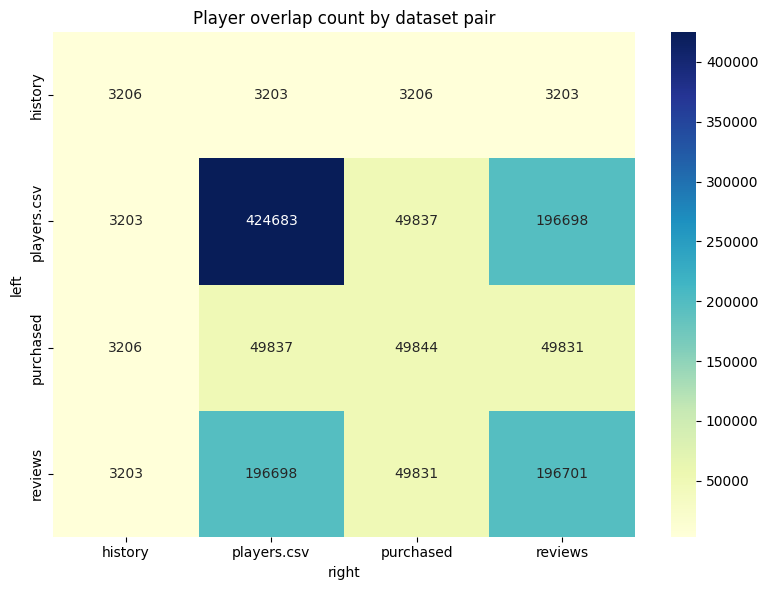


[S2.4] Detail table - overlap matrix (history, purchased, reviews, players.csv):


right,history,players.csv,purchased,reviews
left,,,,
history,3206,3203,3206,3203
players.csv,3203,424683,49837,196698
purchased,3206,49837,49844,49831
reviews,3203,196698,49831,196701


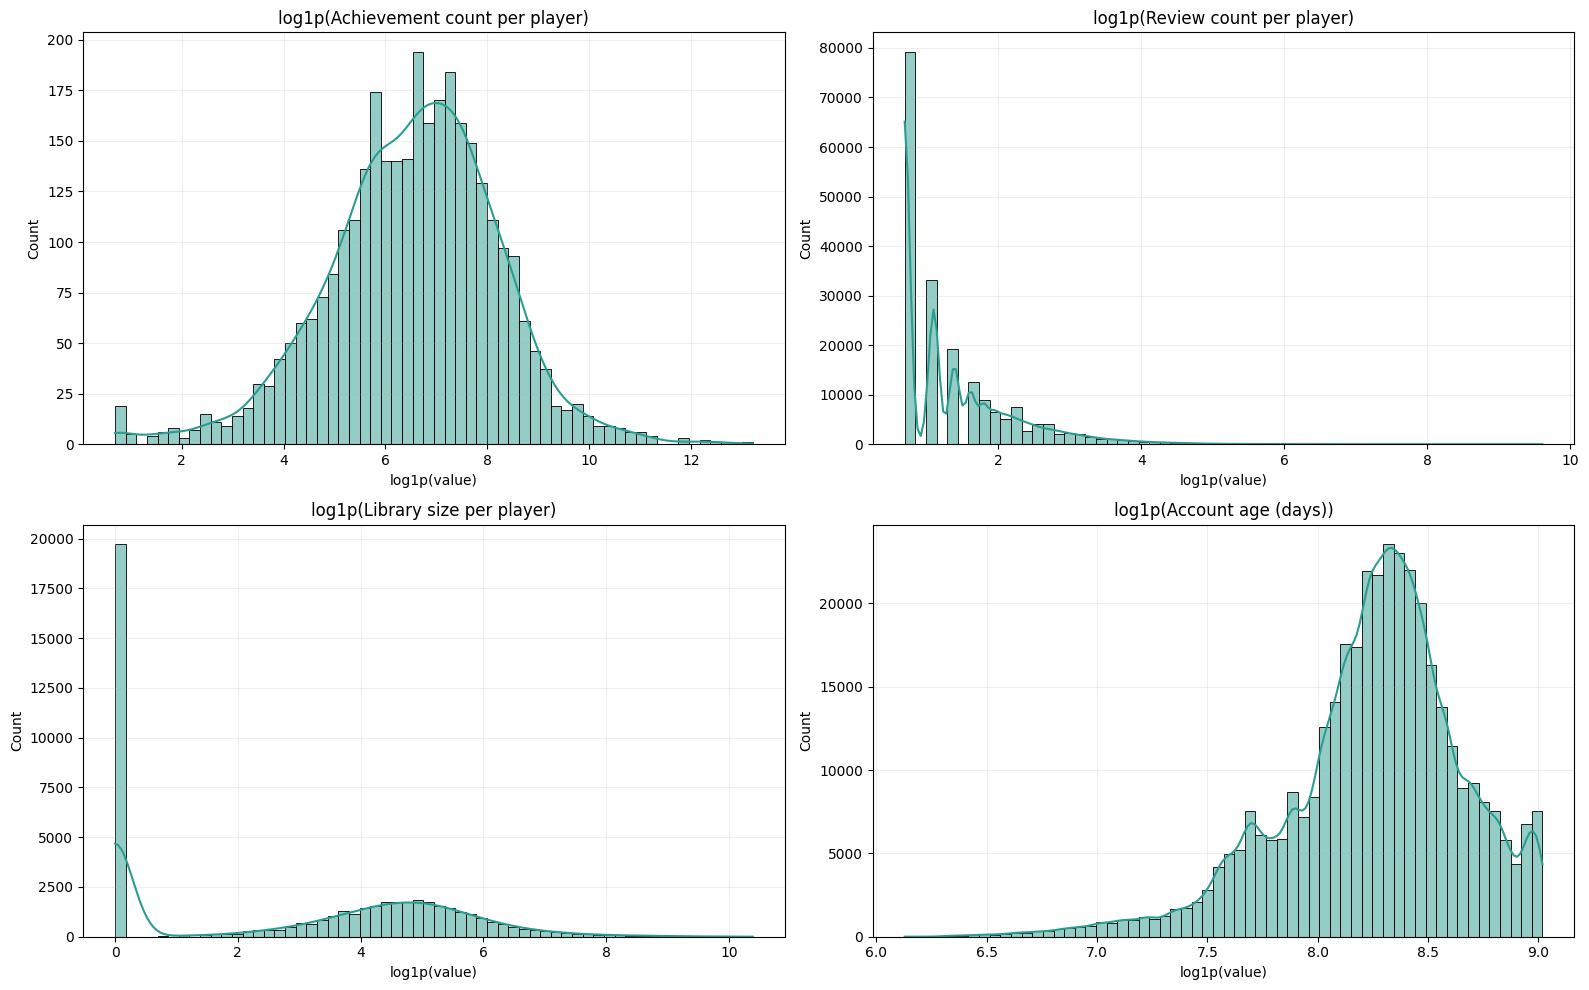


[S2.4] Detail table - distribution summary:


,count,mean,std,min,50%,90%,95%,99%,max
achievements_per_player,3206.0,2888.35,14941.08,1.0,774.5,4823.0,8171.0,35991.80,545949.0
reviews_per_player,196701.0,6.12,50.41,1.0,2.0,12.0,20.0,60.00,14893.0
library_size,49844.0,193.24,819.06,0.0,35.0,367.0,658.0,2697.85,32463.0
account_age_days,377014.0,4122.98,1533.19,458.0,4004.0,6262.0,7129.0,8157.00,8248.0


In [17]:
print("\n[S2.4] Visual consistency checks...")
player_sets = {
    'history': ach_players,
    'players.csv': players_players,
    'purchased': pur_players,
    'reviews': rev_players,
}
coverage_rows = []
dataset_names = list(player_sets.keys())
for left in dataset_names:
    for right in dataset_names:
        left_set = player_sets[left]
        right_set = player_sets[right]
        coverage_rows.append({
            'left': left,
            'right': right,
            'count': len(left_set & right_set),
        })
coverage_pivot = pd.DataFrame(coverage_rows).pivot(index='left', columns='right', values='count')
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(coverage_pivot, annot=True, fmt='g', cmap='YlGnBu', ax=ax)
ax.set_title('Player overlap count by dataset pair')
plt.tight_layout()
plt.show()
plt.close()

print("\n[S2.4] Detail table - overlap matrix (history, purchased, reviews, players.csv):")
display(coverage_pivot)

lib_size = purchased.set_index('playerid')['library_size'].rename('library_size')
players_raw_full = pd.read_csv(RAW_DIR / 'players.csv', usecols=['playerid', 'created']).drop_duplicates(subset=['playerid'], keep='last')
players_raw_full['created'] = pd.to_datetime(players_raw_full['created'], errors='coerce')
players_age = (pd.Timestamp.now() - players_raw_full.set_index('playerid')['created']).dt.days.rename('account_age_days')
dist_df = pd.concat([
    ach_per_player.rename('achievements_per_player'),
    rev_per_player.rename('reviews_per_player'),
    lib_size,
    players_age,
], axis=1)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
plot_specs = [
    ('achievements_per_player', 'Achievement count per player'),
    ('reviews_per_player', 'Review count per player'),
    ('library_size', 'Library size per player'),
    ('account_age_days', 'Account age (days)'),
]
for ax, (col, title) in zip(axes.flatten(), plot_specs):
    series = dist_df[col].dropna()
    if series.empty:
        ax.set_axis_off()
        continue
    sns.histplot(np.log1p(series), bins=60, kde=True, ax=ax, color='#2a9d8f')
    ax.set_title(f'log1p({title})')
    ax.set_xlabel('log1p(value)')
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()
plt.close()

print("\n[S2.4] Detail table - distribution summary:")
display(dist_df.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T.round(2))

**Bảng `history.csv` (Achievements)**

- Trung bình mỗi người chơi có `2,888.35` thành tựu.
- Độ lệch chuẩn rất cao (`14,941.08`), cho thấy phân bố rất rộng: một số ít người chơi có rất nhiều thành tựu, trong khi đa số có số lượng thấp.
- 90% người chơi có tối đa `4,823` thành tựu.
- 99% người chơi có tối đa `35,991` thành tựu.

**Bảng `purchased_games.csv` (Purchased Apps)**

- Trung bình mỗi người chơi có `193.24` trò chơi trong thư viện.
- Độ lệch chuẩn cao (`819.06`), cho thấy thư viện trò chơi phân tán mạnh giữa các người chơi.
- 90% người chơi có tối đa `367` trò chơi.
- 99% người chơi có tối đa `2,698` trò chơi.

**Bảng `purchased_games.csv` (Total Playtime)**

- Trung bình mỗi người chơi có `456,613.27` phút chơi.
- Độ lệch chuẩn rất lớn (`1,693,414.56` phút), cho thấy phân bố thời gian chơi cực kỳ lệch.
- Max đạt `80,260,866` phút.
- 90% người chơi có tối đa `877,014` phút chơi.
- 99% người chơi có tối đa `2,238,362` phút chơi.

**Bảng `reviews.csv` (Reviews)**

- Trung bình mỗi người chơi có `6.12` đánh giá.
- Độ lệch chuẩn cao (`50.41`), cho thấy có một số người chơi đánh giá rất nhiều.
- Max đạt `14,893` đánh giá.
- 90% người chơi có tối đa `12` đánh giá.
- 99% người chơi có tối đa `60` đánh giá.

**Bảng `players.csv` (Account Age)**

- Trung bình độ tuổi tài khoản là `4,122.87` ngày, tương đương khoảng `11.3` năm.
- Độ lệch chuẩn là `1,533.2` ngày, phản ánh sự chênh lệch lớn giữa tài khoản mới và tài khoản lâu năm.
- 90% người chơi có độ tuổi tài khoản ít nhất `4,004` ngày.
- 99% người chơi có độ tuổi tài khoản ít nhất `6,262` ngày.
- Khoảng giá trị quan sát được: từ `458` ngày đến `8,248` ngày.

## 3. Behavioral EDA

### Q1. Có tồn tại các cụm tài khoản sở hữu tốc độ đạt thành tựu bất thường hay không?


[Q1] Generating chart: Playtime per Achievement...


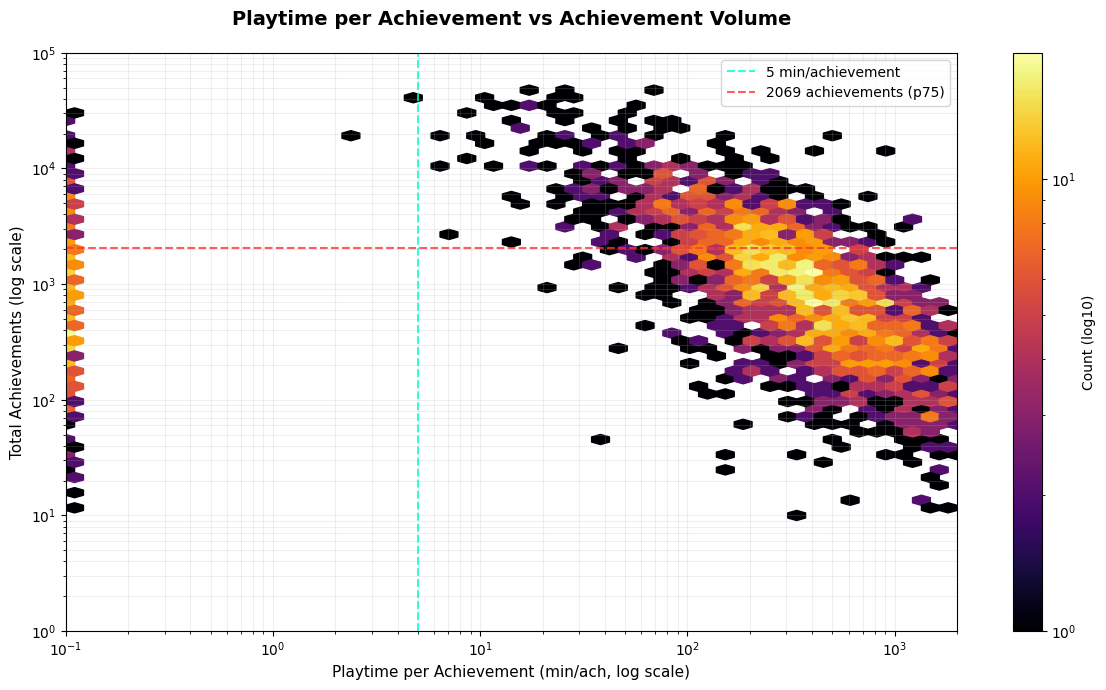

[Q1] Summary:
  - Users analyzed: 2,940
  - Extreme-region users (<=5 min/achievement & >=2069 achievements): 79
  - p1 playtime/achievement: 0.00 min
  - p99 achievements: 37515

[Q1] Detail table (describe):


,count,mean,std,min,25%,50%,75%,max
total_playtime_mins,2940.0,456009.534694,1.694863e+06,0.0,131708.500000,294362.500000,537237.250000,8.026087e+07
total_achievements,2940.0,2987.762925,1.554677e+04,10.0,268.000000,789.000000,2069.250000,5.459490e+05
playtime_per_achievement,2940.0,948.844346,2.887073e+03,0.0,143.822076,350.220363,786.315581,9.064409e+04


In [18]:
# ============================================================
# CHART 1: PLAYTIME PER ACHIEVEMENT ANALYSIS
# ============================================================
print("\n[Q1] Generating chart: Playtime per Achievement...")

def _sum_playtime_minutes(library):
    """Calculate total playtime from structured library data."""
    if not isinstance(library, (list, np.ndarray, pd.Series)):
        return np.nan

    total_mins = 0.0
    valid = False
    for item in library:
        if isinstance(item, dict):
            try:
                p_min = float(item.get("playtime_mins", 0))
                if p_min >= 0:
                    total_mins += p_min
                    valid = True
            except (TypeError, ValueError):
                continue
    return total_mins if valid else np.nan

# --- 1) Data preparation ---
playtime_df = purchased[["playerid", "library"]].drop_duplicates(subset=["playerid"]).copy()
playtime_df["total_playtime_mins"] = playtime_df["library"].apply(_sum_playtime_minutes)

playtime_stats = pd.concat([
    playtime_df.set_index("playerid")["total_playtime_mins"],
    history.groupby("playerid").size().rename("total_achievements"),
], axis=1).dropna(subset=["total_playtime_mins", "total_achievements"])

playtime_stats["playtime_per_achievement"] = (
    playtime_stats["total_playtime_mins"] / playtime_stats["total_achievements"].replace(0, np.nan)
)

plot_df = playtime_stats[
    (playtime_stats["playtime_per_achievement"] >= 0)
    & (playtime_stats["total_achievements"] > 0)
].copy()

# --- 2) Visualization ---
mask = (plot_df["playtime_per_achievement"] < 2000) & (plot_df["total_achievements"] < 50000)
d_x = plot_df.loc[mask, "playtime_per_achievement"].clip(lower=0.1)
d_y = plot_df.loc[mask, "total_achievements"]

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
hb = ax.hexbin(
    d_x,
    d_y,
    gridsize=50,
    bins="log",
    cmap="inferno",
    mincnt=1,
    xscale="log",
    yscale="log",
)

ax.set_xlim(0.1, 2000)
ax.set_ylim(1, 100000)
ax.axvline(5, color="#00ffcc", linestyle="--", alpha=0.8, label="5 min/achievement")
ax.axhline(2069, color="#ff3333", linestyle="--", alpha=0.8, label="2069 achievements (p75)")

cb = fig.colorbar(hb, ax=ax)
cb.set_label("Count (log10)", fontsize=10)

ax.set_title("Playtime per Achievement vs Achievement Volume", fontsize=14, fontweight="bold", pad=20)
ax.set_xlabel("Playtime per Achievement (min/ach, log scale)", fontsize=11)
ax.set_ylabel("Total Achievements (log scale)", fontsize=11)
ax.legend(frameon=True, facecolor="white", framealpha=0.8)
ax.grid(alpha=0.2, which="both")

plt.tight_layout()
plt.show()
plt.close()

# --- 3) Summary logs ---
# Threshold: p75 (2069) = top 25% active players. At p75, extreme bots represent
# ~10% of players, providing a meaningful signal while filtering noise from casual players.
extreme_mask = (
    (playtime_stats["playtime_per_achievement"] <= 5)
    & (playtime_stats["total_achievements"] >= 2069)
)
suspicious_player_ids = set(playtime_stats.index[extreme_mask])

print("[Q1] Summary:")
print(f"  - Users analyzed: {len(plot_df):,}")
print(f"  - Extreme-region users (<=5 min/achievement & >=2069 achievements): {extreme_mask.sum():,}")
print(f"  - p1 playtime/achievement: {plot_df['playtime_per_achievement'].quantile(0.01):.2f} min")
print(f"  - p99 achievements: {plot_df['total_achievements'].quantile(0.99):.0f}")

print("\n[Q1] Detail table (describe):")
display(playtime_stats.describe().T)

#### 1. Biểu đồ và phân tích

Biểu đồ hexbin mô tả mối quan hệ giữa `playtime_per_achievement` và `total_achievements` trong tập người chơi được giữ lại sau khi lọc dữ liệu hợp lệ.

- Trục ngang: `playtime_per_achievement` (phút/achievement, thang log).
- Trục dọc: `total_achievements` (thang log).
- Màu sắc: mật độ điểm dữ liệu (log scale).

Biểu đồ cho thấy phân bố rất rộng giữa số lượng thành tựu và thời gian chơi trung bình cho mỗi thành tựu. Nhóm ở phía trên bên phải đại diện cho người chơi có nhiều thành tựu và chơi lâu hơn, trong khi vùng dưới bên trái thường gắn với các tài khoản có tốc độ đạt thành tựu bất thường.

#### 2. Thông tin từ bảng thống kê chi tiết

- Số người chơi được phân tích sau khi lọc dữ liệu hợp lệ: `2,940`.
- Các tài khoản có `playtime_per_achievement` cực thấp và `total_achievements` rất cao có thể là dấu hiệu của bot, ghost account hoặc hành vi không hợp lệ khác.
- `total_achievements` trải từ `10` đến `545,949`.
- `playtime_per_achievement` có giá trị trung bình `948.84` phút và độ lệch chuẩn `2,887.07` phút.

### Q2. Tính chính danh của người dùng thể hiện như thế nào qua hành vi đánh giá?

In [ ]:
# ============================================================
# CHART 2: OWNERSHIP vs REVIEW BEHAVIOR (SCATTER)
# ============================================================
print("\n[Q2] Generating chart: Ownership vs Review Behavior...")

def parse_library_appids(value):
    if value is None:
        return set()
    if isinstance(value, (np.ndarray, list, tuple, set, pd.Series)):
        out = set()
        for item in value:
            if item is None:
                continue
            if isinstance(item, dict):
                appid = item.get("appid")
            else:
                appid = item
            try:
                out.add(int(appid))
            except (TypeError, ValueError):
                continue
        return out
    text = str(value).strip()
    if not text or text.lower() == "nan":
        return set()
    nums = pd.Series([text]).str.findall(r"\d+").iloc[0]
    return {int(x) for x in nums}

library_map = {
    int(row.playerid): parse_library_appids(row.library)
    for row in purchased[["playerid", "library"]].itertuples(index=False)
}

reviews_copy = reviews[["playerid", "gameid", "review"]].copy()
reviews_copy["review"] = reviews_copy["review"].fillna("").astype(str)
reviews_copy["review_norm"] = reviews_copy["review"].str.lower().str.strip()

def compute_review_behavior(group):
    pid = int(group.name)
    lib = library_map.get(pid, set())
    gameids = pd.to_numeric(group["gameid"], errors="coerce").dropna().astype(int)
    if len(lib) > 0 and len(gameids) > 0:
        unowned_ratio = (~gameids.isin(lib)).mean()
    else:
        unowned_ratio = np.nan
    total_reviews = len(group)
    dup_rate = group["review_norm"].duplicated().mean() if total_reviews > 0 else np.nan
    return pd.Series({
        "total_reviews": total_reviews,
        "review_unowned_ratio": unowned_ratio,
        "review_duplication_rate": dup_rate,
    })

review_behavior_df = reviews_copy.groupby("playerid").apply(compute_review_behavior, include_groups=False)
review_behavior_df["total_achievements"] = history.groupby("playerid").size()
review_behavior_df = review_behavior_df.dropna(subset=["review_unowned_ratio", "review_duplication_rate", "total_achievements"])

plot_df = review_behavior_df[review_behavior_df["total_reviews"] > 0].copy()
size_ref = plot_df["total_reviews"].clip(upper=plot_df["total_reviews"].quantile(0.95))
point_size = 20 + 180 * (size_ref / size_ref.max()) if len(plot_df) > 0 else []

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
sc = ax.scatter(
    plot_df["review_unowned_ratio"],
    plot_df["total_achievements"].clip(lower=1),
    c=plot_df["review_duplication_rate"],
    s=point_size,
    cmap="viridis",
    alpha=0.7,
    edgecolors="none",
)
cb = fig.colorbar(sc, ax=ax)
cb.set_label("review_duplication_rate", fontsize=10)

ax.set_yscale("log")
ax.set_xlim(-0.02, 1.02)
ax.set_title("Ownership vs Review Behavior", fontsize=14, fontweight="bold")
ax.set_xlabel("review_unowned_ratio", fontsize=12, fontweight="bold")
ax.set_ylabel("total_achievements (log scale)", fontsize=12, fontweight="bold")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()
plt.close()

risk_cluster = (
    (plot_df["review_unowned_ratio"] >= 0.7)
    & (plot_df["review_duplication_rate"] >= 0.2)
)

print("[Q2] Summary:")
print(f"  - Users plotted: {len(plot_df):,}")
print(f"  - High-unowned/high-dup users: {int(risk_cluster.sum()):,}")
print(f"  - Median total_reviews: {plot_df['total_reviews'].median():.1f}")

print("\n[Q2] Detail table (top 20 by review_unowned_ratio):")
display(
    review_behavior_df.sort_values(
        ["review_unowned_ratio", "review_duplication_rate", "total_reviews"],
        ascending=[False, False, False],
    ).head(20)
)


[Q2] Generating chart: Ownership vs Review Behavior...


#### **Biểu đồ và Phân tích**

Biểu đồ **Ownership vs Review Behavior** mô tả mối quan hệ giữa **Ownership Ratio** (tỷ lệ game chưa sở hữu trong đánh giá) và **Review Behavior** (hành vi đánh giá) của người chơi:

* **Trục ngang**: **review_unowned_ratio** (tỷ lệ game chưa sở hữu trong đánh giá).
* **Trục dọc**: **total_achievements** (tổng số thành tựu), trên thang log.
* **Màu sắc**: Đại diện cho **review_duplication_rate** (tỷ lệ sao chép trong đánh giá).
* **Kích thước điểm**: Tương ứng với số lượng đánh giá của người chơi (total_reviews).

Biểu đồ cho thấy mối quan hệ giữa tỷ lệ game chưa sở hữu và số lượng thành tựu. Các tài khoản với **review_unowned_ratio cao** (tỷ lệ game không sở hữu cao) và **review_duplication_rate** (tỷ lệ sao chép đánh giá) cao có thể là dấu hiệu của hành vi **gian lận** hoặc **kém chính danh**.
       |

* **Review Unowned Ratio**: Một số người chơi có tỷ lệ **review_unowned_ratio = 1.0**, tức là họ đang đánh giá các trò chơi mà họ **không sở hữu**. Đây là dấu hiệu của **hành vi bất thường**, có thể liên quan đến **gian lận** hoặc **spam**.

Cụm Tập trung (The Main Core): Đa số các điểm tập trung ở góc trái biểu đồ ($unowned\_ratio \approx 0$). Điều này phản ánh hành vi "chơi thật - học thật": người dùng sở hữu game rồi mới viết đánh giá. Đây là nhóm có độ tin cậy cao nhất.

Dải Bất thường (The Vertical Spikes): Xuất hiện các cột dữ liệu chạy dọc tại các mốc đặc biệt như 0.5 và 1.0.Tại mức 1.0, người dùng đánh giá rất nhiều game nhưng không sở hữu bất kỳ game nào trong số đó. Đây là hành vi phi thực tế đối với một người chơi thông thường.

Các điểm có màu sáng (vàng/xanh) thể hiện tỷ lệ sao chép nội dung cao. Khi các điểm này xuất hiện ở vùng có unowned_ratio cao, nó củng cố giả thuyết về các chiến dịch spam nội dung có hệ thống.

Quy mô (Size): Những vòng tròn lớn ở vùng có chỉ số bất thường cho thấy có những tài khoản thực hiện hàng trăm, hàng ngàn lượt review "ảo". Dù họ có tổng thành tựu (total_achievements) cao hay thấp, việc thiếu quyền sở hữu game vẫn là một điểm yếu logic lớn trong dữ liệu.

### Q3. Thành tựu có được phân bổ đa dạng giữa các trò chơi hay tập trung quá mức vào một nhóm nhỏ trò chơi?


[Q3] Generating chart: Game Portfolio Concentration...


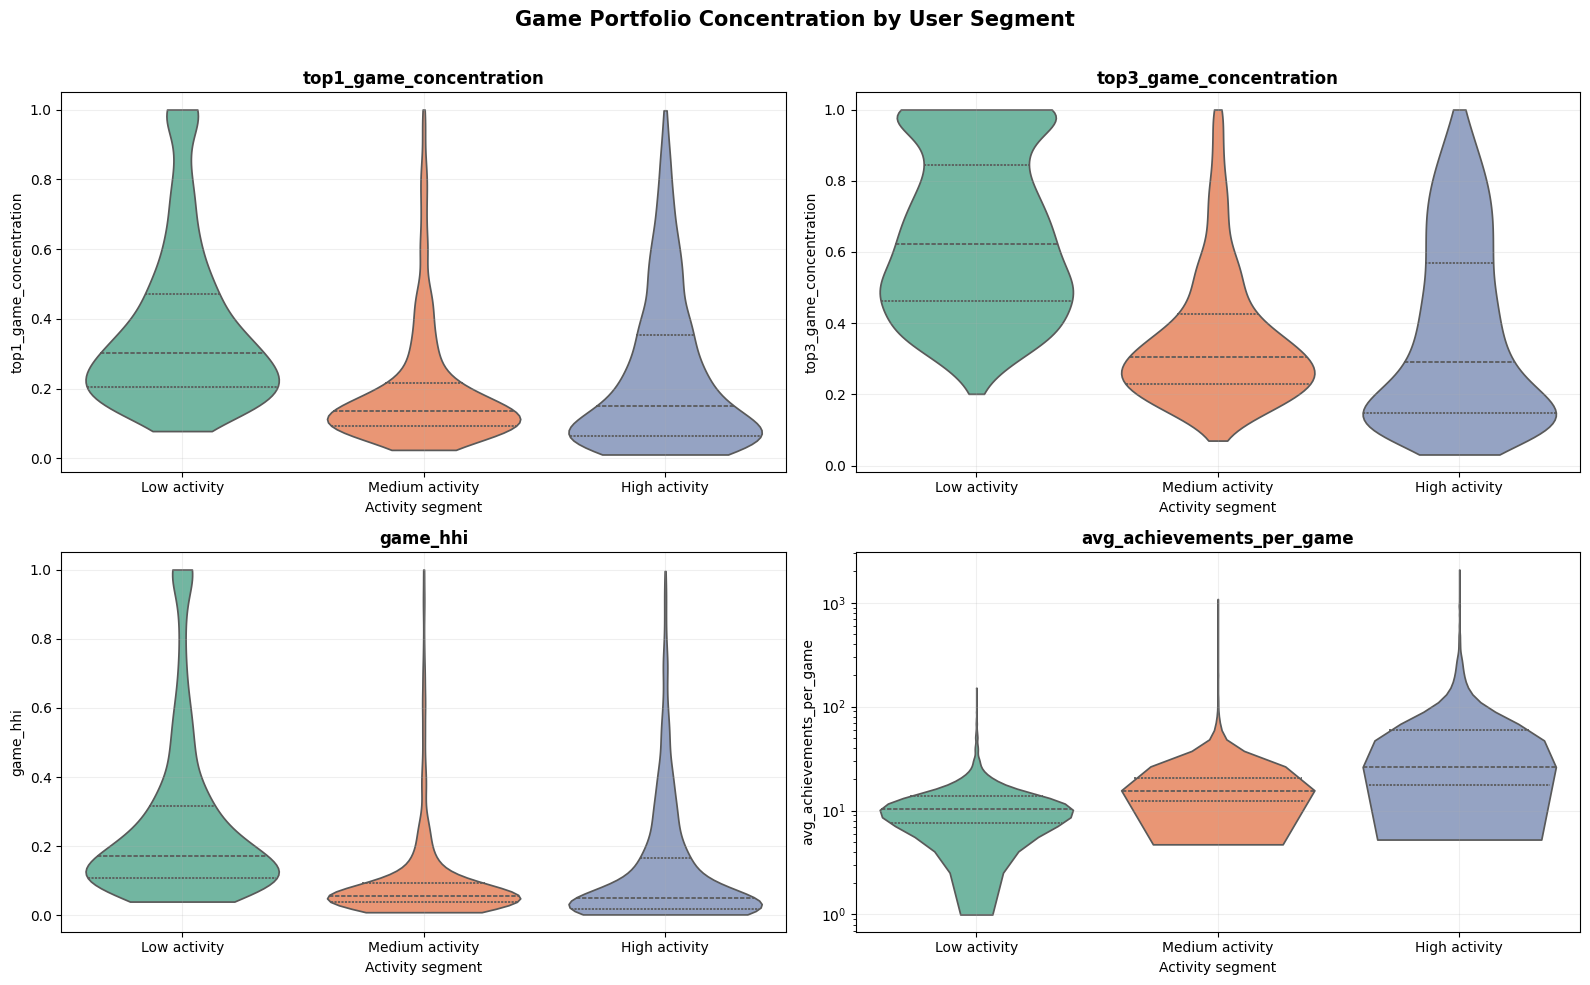

[Q3] Summary:
  - Users plotted: 3,206
  - Segments: 3

[Q3] Detail table (median by segment):


,top1_game_concentration,top3_game_concentration,game_hhi,avg_achievements_per_game
activity_segment,,,,
Low activity,0.303419,0.623529,0.172023,10.454545
Medium activity,0.136298,0.306020,0.056498,15.466667
High activity,0.151516,0.292305,0.051291,26.353449


In [ ]:
# ============================================================
# CHART 3: GAME PORTFOLIO CONCENTRATION (VIOLIN)
# ============================================================
print("\n[Q3] Generating chart: Game Portfolio Concentration...")

game_counts = history.groupby(["playerid", "gameid"]).size()
total_ach = history.groupby("playerid").size().rename("total_achievements")
games_with_ach = history.groupby("playerid")["gameid"].nunique().rename("games_with_achievements")

game_props = game_counts / game_counts.groupby(level=0).sum()
portfolio_df = pd.concat([
    total_ach,
    (game_props.groupby(level=0).max().rename("top1_game_concentration")),
    (game_props.groupby(level=0).apply(lambda x: x.nlargest(3).sum()).rename("top3_game_concentration")),
    ((game_props ** 2).groupby(level=0).sum().rename("game_hhi")),
    (total_ach / games_with_ach).rename("avg_achievements_per_game"),
], axis=1).dropna()

try:
    portfolio_df["activity_segment"] = pd.qcut(
        portfolio_df["total_achievements"],
        q=3,
        labels=["Low activity", "Medium activity", "High activity"],
        duplicates="drop",
    )
except ValueError:
    portfolio_df["activity_segment"] = "All users"

metrics = [
    "top1_game_concentration",
    "top3_game_concentration",
    "game_hhi",
    "avg_achievements_per_game",
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    sns.violinplot(
        data=portfolio_df,
        x="activity_segment",
        y=metric,
        inner="quartile",
        cut=0,
        palette="Set2",
        ax=ax,
    )
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_xlabel("Activity segment")
    ax.set_ylabel(metric)
    ax.grid(alpha=0.2)
    if metric == "avg_achievements_per_game":
        ax.set_yscale("log")

plt.suptitle("Game Portfolio Concentration by User Segment", fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
plt.close()

print("[Q3] Summary:")
print(f"  - Users plotted: {len(portfolio_df):,}")
print(f"  - Segments: {portfolio_df['activity_segment'].nunique()}")

print("\n[Q3] Detail table (median by segment):")
display(portfolio_df.groupby("activity_segment")[metrics].median())

#### 1. **Biểu đồ và Phân tích**

Biểu đồ **Game Portfolio Concentration by User Segment** cho thấy sự phân bố **thành tựu** của người chơi trong các nhóm hoạt động khác nhau:

* **Trục ngang**:

  * **top1_game_concentration**: Tỷ lệ thành tựu đạt được trong game đầu tiên (mức độ tập trung vào game đầu tiên).
  * **top3_game_concentration**: Tỷ lệ thành tựu đạt được trong 3 game đầu tiên (mức độ tập trung vào ba game hàng đầu).
  * **game_hhi**: Chỉ số **Herfindahl-Hirschman Index (HHI)** đo lường mức độ tập trung của thành tựu trong danh mục game.
  * **avg_achievements_per_game**: Số lượng thành tựu trung bình cho mỗi trò chơi.

* **Trục dọc**: Các nhóm người chơi được phân chia thành 3 nhóm:

  * **Low activity**: Người chơi có hoạt động thấp.
  * **Medium activity**: Người chơi có hoạt động trung bình.
  * **High activity**: Người chơi có hoạt động cao.

Các biểu đồ cho thấy:

* **Top 1 & Top 3 Game Concentration**: Tỷ lệ tập trung thành tựu vào các game hàng đầu.
* **Game HHI**: Chỉ số này càng cao, thành tựu càng tập trung vào ít game hơn.

#### **2. Quan sát sự phân hóa theo phân đoạn người dùng (Segments)**

#### **Phân đoạn Low Activity (Cường độ thấp)**:

* **HHI trung bình cao nhất** (**0.1720**) cho thấy các người chơi này có xu hướng tập trung thành tựu vào một số ít trò chơi.
* **Phân phối Violin phình to ở các ngưỡng nồng độ cao**, cho thấy các tài khoản có ít game nhưng lại tập trung thành tựu vào một vài game.
* **Giải thích**: Người chơi có ít trò chơi trong danh mục thường có thành tựu tập trung vào những game đó, dẫn đến sự thiếu đa dạng trong trải nghiệm.

#### **Phân đoạn Medium & High Activity (Cường độ trung bình và cao)**:

* **HHI giảm mạnh** từ **0.0565 đến 0.0513** cho thấy sự phân bổ thành tựu rộng rãi hơn giữa các game.
* **Phân phối Violin tập trung chủ yếu ở vùng đáy (giá trị thấp)**, điều này chỉ ra rằng các người chơi trong nhóm này có xu hướng trải nghiệm nhiều game, và thành tựu được phân bổ đều hơn.
* **Đặc điểm**: Các người chơi có cường độ hoạt động cao (Medium & High Activity) thường không tập trung vào một số ít trò chơi, mà đa dạng hóa thành tựu giữa nhiều tựa game khác nhau.

#### **Sự tồn tại của các trường hợp dị biệt (Outliers)**:

* **Dải dữ liệu mỏng kéo dài đến ngưỡng 1.0** trong biểu đồ **HHI** và **Top-1**, cho thấy những trường hợp **Dedicated Focus**.
* **Nhận định**: Những trường hợp này phản ánh hành vi **chuyên dụng** (Dedicated Focus), tức là người chơi đạt thành tựu lớn nhưng chỉ tập trung vào một trò chơi duy nhất.

### **3. Hiệu suất đạt thành tựu (Avg Achievements)**:

* **Biểu đồ avg_achievements_per_game** cho thấy nhóm **High Activity** có **đỉnh Violin cao hơn đáng kể**, chỉ ra rằng họ có **hiệu suất cao hơn** trên mỗi tựa game.
* **Nhóm người chơi High Activity** thể hiện **hành vi chơi game tự nhiên**, với **nồng độ tập trung thấp** (HHI thấp) và **hiệu suất cao trên mỗi game** (avg_achievements cao).
* **Tính quy luật**: Những người chơi có hoạt động tích cực có sự kết hợp giữa việc **đa dạng hóa thành tựu** và **hiệu suất đạt thành tựu cao** trên nhiều game.


### Q4. Sự khác biệt về nhịp độ hoạt động giữa nhóm người dùng cực đoan và các người dùng còn lại là gì?


[Q4] Generating chart: Temporal Activity Patterns...


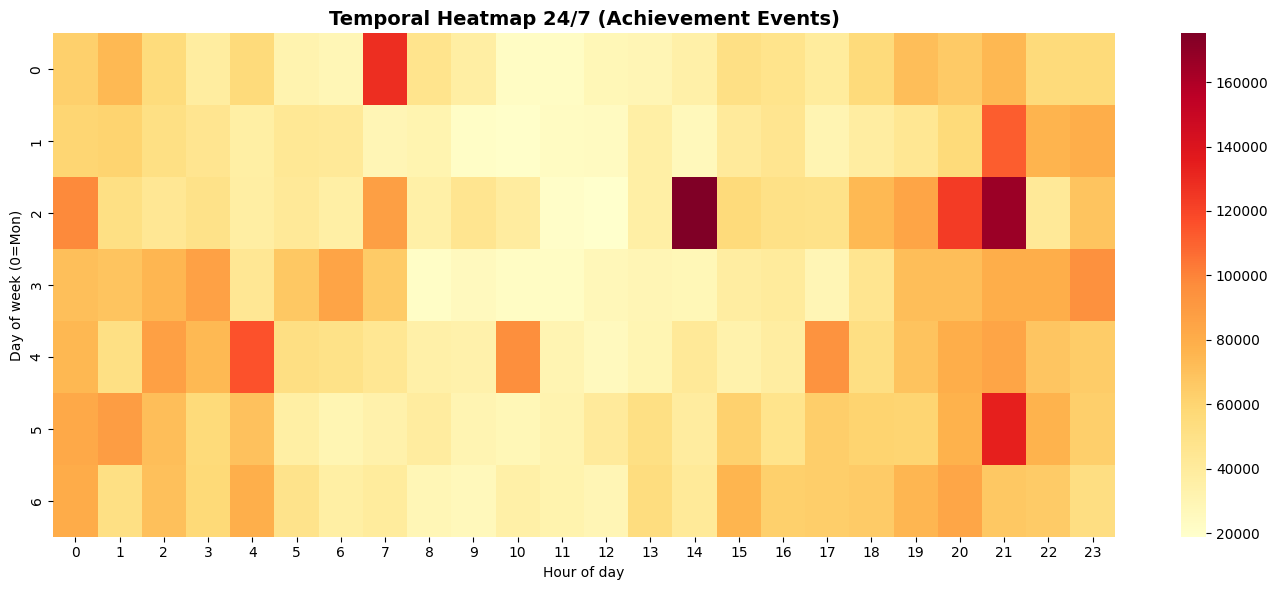


[Q4] Group definition:
  - Extreme pattern group: playtime_per_achievement <= 5 AND total_achievements >= 2069 (p75)
  - Reference group: all remaining players
  - Extreme players in chart: 79
  - Reference players in chart: 3,124


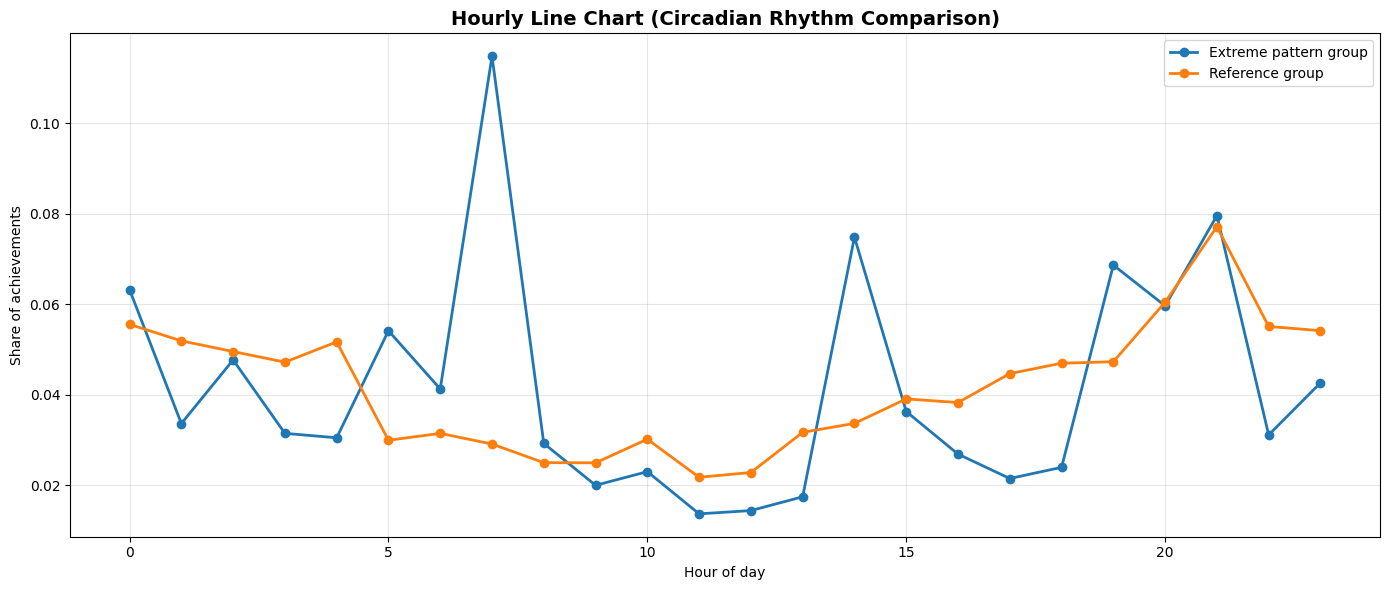

[Q4] Summary:
  - Heatmap events: 9,257,076
  - Groups in line chart: 2 (Extreme pattern group, Reference group)

[Q4] Detail table (24x7 heatmap matrix):


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
dow,,,,,,,,,,,,,,,,,,,,,
0,62388,73838,54910,38878,55595,32088,29257,128493,47493,37289,...,35275,50721,47724,40185,55625,71688,65394,74903,55765,56526
1,59467,60764,51839,46217,37066,43832,42391,29732,31369,21493,...,26487,41089,45783,30681,38308,45016,56145,112200,76500,79419
2,98052,51443,44305,48820,37308,42137,36379,87303,35485,46323,...,175128,55592,50110,49274,74265,84789,123404,166182,42504,68876
3,70793,68730,75446,86165,44249,66589,85348,65197,21555,25391,...,28357,38189,40632,29358,45947,71981,71883,79796,79746,94584
4,74978,51448,86931,74257,115831,52377,49672,45081,35278,34134,...,42113,33264,38247,93453,52114,69094,79855,84379,68182,64532
5,82273,88848,71454,56499,70143,36907,30113,33551,39281,30760,...,39561,62098,48183,63721,60540,60148,77592,134237,77357,63047
6,80631,51416,70372,56899,78771,48638,36656,40234,29154,26648,...,41772,75776,62607,63734,65169,75062,83787,66780,65225,52925


In [ ]:
# ============================================================
# CHART 4: TEMPORAL ACTIVITY PATTERNS (HEATMAP + HOURLY LINE)
# ============================================================
print("\n[Q4] Generating chart: Temporal Activity Patterns...")

history_time = history[["playerid", "date_acquired"]].dropna(subset=["date_acquired"]).copy()
history_time["hour"] = history_time["date_acquired"].dt.hour
history_time["dow"] = history_time["date_acquired"].dt.dayofweek

# Heatmap 24/7 from raw achievement events
heat_24x7 = (
    history_time.groupby(["dow", "hour"]).size()
    .unstack(fill_value=0)
    .reindex(index=range(7), columns=range(24), fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heat_24x7, cmap="YlOrRd", ax=ax)
ax.set_title("Temporal Heatmap 24/7 (Achievement Events)", fontsize=14, fontweight="bold")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Day of week (0=Mon)")
plt.tight_layout()
plt.show()
plt.close()

# Hourly line chart: reference vs extreme group from Chart 1 criteria
suspicious_player_ids = suspicious_player_ids if "suspicious_player_ids" in globals() else set()

print("\n[Q4] Group definition:")
print("  - Extreme pattern group: playtime_per_achievement <= 5 AND total_achievements >= 2069 (p75)")
print("  - Reference group: all remaining players")

all_players_in_chart4 = set(history_time["playerid"].unique())
n_extreme_players = len(all_players_in_chart4 & suspicious_player_ids)
n_reference_players = len(all_players_in_chart4 - suspicious_player_ids)
print(f"  - Extreme players in chart: {n_extreme_players:,}")
print(f"  - Reference players in chart: {n_reference_players:,}")

history_time["group"] = np.where(
    history_time["playerid"].isin(suspicious_player_ids),
    "Extreme pattern group",
    "Reference group",
)

hourly_share = history_time.groupby(["group", "hour"]).size().rename("n").reset_index()
hourly_share["share"] = hourly_share["n"] / hourly_share.groupby("group")["n"].transform("sum")

fig, ax = plt.subplots(figsize=(14, 6))
for grp, gdf in hourly_share.groupby("group"):
    ax.plot(gdf["hour"], gdf["share"], marker="o", linewidth=2, label=grp)
ax.set_title("Hourly Line Chart (Circadian Rhythm Comparison)", fontsize=14, fontweight="bold")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Share of achievements")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
plt.close()

group_names = ", ".join(sorted(hourly_share["group"].unique()))
print("[Q4] Summary:")
print(f"  - Heatmap events: {len(history_time):,}")
print(f"  - Groups in line chart: {hourly_share['group'].nunique()} ({group_names})")

print("\n[Q4] Detail table (24x7 heatmap matrix):")
display(heat_24x7)

#### 1. **Biểu đồ và Phân tích**

Chúng ta có **hai biểu đồ** để phân tích sự khác biệt về nhịp độ hoạt động giữa nhóm người dùng cực đoan và các người dùng còn lại:

* **Chart 4a: Temporal Heatmap 24/7** (biểu đồ nhiệt): Mô tả **mẫu hoạt động theo thời gian trong ngày và tuần** (tần suất các sự kiện thành tựu diễn ra vào từng giờ trong các ngày trong tuần).
* **Chart 4b: Hourly Line Chart**: So sánh **nhịp sinh học** của nhóm **Extreme Pattern** với nhóm tham chiếu **Reference group** theo từng giờ trong ngày.

#### 2. **Tiêu chí phân nhóm thực nghiệm**:

* **Extreme Pattern Group**:

  * Điều kiện: **`playtime_per_achievement <= 5` phút** và **`total_achievements >= 2069` (p75 percentile)**. Đây là nhóm người chơi có hoạt động đạt thành tựu cực nhanh (tốc độ đạt thành tựu bất thường).
* **Reference Group**:

  * Các người chơi còn lại, không thuộc nhóm **Extreme Pattern**.

#### 3. **Biểu đồ 4a: Temporal Heatmap 24/7**

Biểu đồ nhiệt này cho thấy sự phân bổ của các sự kiện thành tựu theo giờ trong ngày và theo ngày trong tuần:
* **Các điểm nóng (Hotspots) bất thường:** Xuất hiện các ô màu đậm cô lập tại khung giờ **7h sáng** và **14h chiều** vào các ngày trong tuần (Thứ 2, Thứ 3, Thứ 5).
* **Nhận định:** Khác với hành vi chơi game thông thường (thường đậm dần vào buổi tối và cuối tuần), các đỉnh nhọn vào giờ hành chính và sáng sớm gợi ý về sự hiện diện của các tác vụ chạy tự động (Scheduled scripts) được thiết lập vào khung giờ cố định.

#### 4. **Biểu đồ 4b: Hourly Line Chart**

Biểu đồ đường này so sánh **share of achievements** của nhóm **Extreme Pattern** và **Reference group** theo từng giờ trong ngày:

* **Nhóm Extreme (Đường màu xanh):** Xuất hiện các biến động gắt (spikes) và có xu hướng nghịch đảo với nhóm đối chứng:
    * **Đỉnh nhọn cực đại tại 7h sáng:** Đây là thời điểm nhóm Reference ở mức hoạt động thấp nhất, cho thấy nhóm Extreme vận hành theo một lịch trình hoàn toàn khác biệt.
    * **Các đỉnh nhọn đột biến:** Tại các mốc 14h và 19h, dữ liệu vọt lên rồi rơi thẳng đứng, phản ánh cường độ hoạt động không ổn định và có tính chất kích hoạt theo thời điểm thay vì duy trì theo sở thích chơi game.

* **Nhóm Reference (Đường màu cam)**:
  * Nhóm này có **share of achievements** phân bố đều hơn trong **các giờ trong ngày**, và đạt đỉnh vào buổi tối (~21h) với sự giảm dần vào ban đêm , thể hiện **nhịp sinh học tự nhiên**.


## 4. Feature Engineering (Xây dựng thuộc tính đặc trưng)
### Group A - Speed Features (6)
1. `median_unlock_interval_sec`: Trung vị khoảng thời gian giữa hai lần mở achievement liên tiếp.
2. `min_unlock_interval_sec`: Khoảng thời gian nhỏ nhất giữa hai lần mở achievement.
3. `std_unlock_interval_sec`: Độ lệch chuẩn của khoảng thời gian mở achievement.
4. `cv_unlock_interval`: Hệ số biến thiên của khoảng thời gian mở achievement (mức độ dao động tương đối).
5. `max_achievements_per_minute`: Số achievement tối đa mở trong một phút.
6. `max_achievements_per_day`: Số achievement tối đa mở trong một ngày.

### Group B - Temporal Features (4)
7. `night_activity_ratio`: Tỷ lệ hoạt động mở achievement trong khung giờ đêm (00:00-05:59).
8. `hour_entropy`: Entropy phân bố theo 24 giờ (càng thấp càng tập trung vào vài khung giờ cố định).
9. `activity_density`: Mật độ hoạt động = số ngày có mở achievement / tổng số ngày span hoạt động.
10. `weekend_ratio`: Tỷ lệ hoạt động rơi vào cuối tuần.

### Group C - Diversity Features (8)
11. `total_achievements`: Tổng số achievement đã mở.
12. `games_with_achievements`: Số game khác nhau có achievement được mở.
13. `library_size`: Số game trong thư viện đã crawl được.
14. `achievement_game_ratio`: Tỷ lệ game có mở achievement trên tổng game thư viện.
15. `top1_game_concentration`: Tỷ trọng achievement tập trung vào game đứng đầu.
16. `top3_game_concentration`: Tỷ trọng achievement tập trung vào 3 game đứng đầu.
17. `game_hhi`: Chỉ số Herfindahl-Hirschman đo mức tập trung achievement theo game.
18. `avg_achievements_per_game`: Trung bình achievement trên mỗi game có hoạt động.

### Group D - Review Features (5)
19. `total_reviews`: Tổng số review của người chơi.
20. `review_unowned_ratio`: Tỷ lệ review cho các game không nằm trong thư viện sở hữu.
21. `review_duplication_rate`: Tỷ lệ review trùng nội dung (lowercase + strip whitespace).
22. `avg_review_length`: Độ dài review trung bình (số ký tự).
23. `min_review_length`: Độ dài review ngắn nhất.

### Group E - Account Age Features (2)
24. `days_before_first_achievement`: Số ngày từ lúc tạo tài khoản tới achievement đầu tiên.
25. `account_age_days`: Tuổi tài khoản tính theo ngày tại thời điểm phân tích.

### Group F - Playtime Plausibility Features (2)
26. `total_playtime_mins`: Tổng playtime (phút) cộng từ dữ liệu thư viện.
27. `playtime_per_achievement`: Playtime trung bình cho mỗi achievement (`total_playtime_mins / total_achievements`).